# Curse of Dimensionality (CoD) Assignment
Angel Chui <br>
Based on Altman, N., Krzywinski, M. The curse(s) of dimensionality. Nat Methods 15, 399–400 (2018). https://doi.org/10.1038/s41592-018-0019-x <br>
ChatGPT was used to help debug

In [10]:
import numpy as np
import matplotlib.pyplot as plt

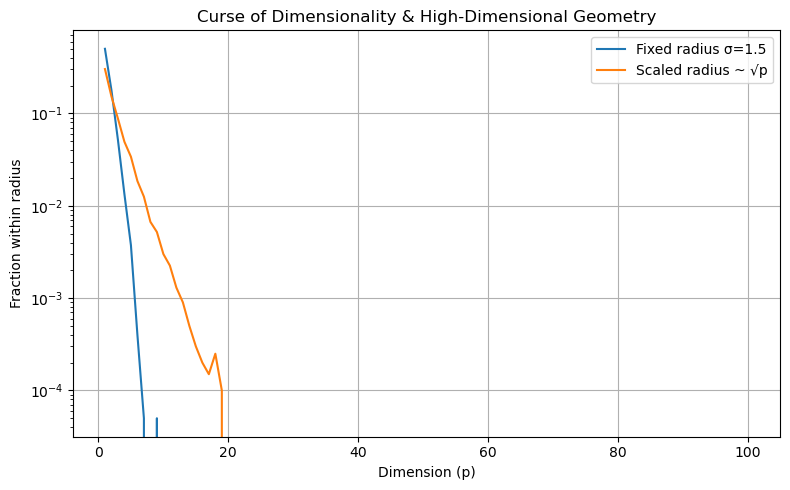

In [12]:
np.random.seed(42)

n = 20000           # number of points
max_p = 100         # dimensions

fractions_fixed = []
fractions_scaled = []

for p in range(1, max_p + 1):
    X = np.random.randn(n, p)     # N(0, I_p)
    center = np.ones(p) * 1.5     # this is sigma (a neighborhood of space with radius of 1.5, similar to Fig. 1 in the paper)
    
    # distances from center
    distances = np.linalg.norm(X - center, axis=1)
    
    # fixed radius σ = 1
    fractions_fixed.append(np.mean(distances <= 1.5))
    
    # scaled radius ~ sqrt(p)
    scaled_radius = np.sqrt(p)
    fractions_scaled.append(np.mean(distances <= scaled_radius))

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, max_p + 1), fractions_fixed, label="Fixed radius σ=1.5")
plt.plot(range(1, max_p + 1), fractions_scaled, label="Scaled radius ~ √p")
plt.yscale('log')
plt.xlabel("Dimension (p)")
plt.ylabel("Fraction within radius")
plt.title("Curse of Dimensionality & High-Dimensional Geometry")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the figure as PNG
plt.savefig("AngelChui_CoD.png", dpi=300)

plt.show()

As seen in the plot, as the number of dimensions increases, the more sparse the data becomes within a neighborhood with both a fixed radius and scaled radius. This recreates in a simpler plot the first concept explained in the paper Altman et al., 2018, where the volume of dimension space the samples occupy may grow with increased dimensionality, but the sparsity also increases. This leads to inaccurate representation of the population.